In [1]:
import numpy as np
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading wordnet: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

Let's Load The Datasets

Training Dataset

In [3]:
import pandas as pd
import re

# Load the raw lines
with open("train.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()

# Parse text and label
texts = []
labels = []

for line in lines:
    parts = line.strip().rsplit(";", 1)  # split from the right
    if len(parts) == 2:
        text, label = parts
        cleaned_text = re.sub(r'[^a-zA-Z ]+', ' ', text).strip().lower()
        if cleaned_text:  # Only keep non-empty cleaned text
            texts.append(cleaned_text)
            labels.append(label.lower().strip())
    else:
        print("Unrecognized format:", line)

# Create DataFrame
df = pd.DataFrame({'text': texts, 'label': labels})
df.head()


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


Validation Dataset

In [4]:
with open("val.txt", "r", encoding="utf-8") as f:
    val_lines = f.readlines()

val_texts = []
val_labels = []

for line in val_lines:
    parts = line.strip().rsplit(";", 1)
    if len(parts) == 2:
        text, label = parts
        val_texts.append(text)
        val_labels.append(label.strip().lower())

val_df = pd.DataFrame({"text": val_texts, "label": val_labels})
val_df.head()


,text,label
0,im feeling quite sad and sorry for myself but ...,sadness
1,i feel like i am still looking at a blank canv...,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy


Exploratory Data Analysis (EDA)

Sentence Lengths

Max sentence length: 66
Avg sentence length: 19.17
Median sentence length: 17.0


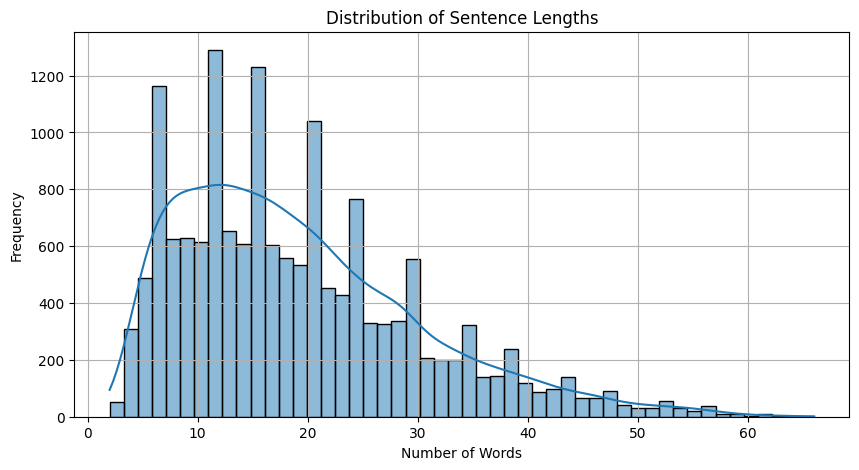

In [5]:
# Tokenize each sentence (basic whitespace split for now)
sentence_lengths = [len(sentence.split()) for sentence in texts]

# Statistics
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Max sentence length: {max(sentence_lengths)}")
print(f"Avg sentence length: {np.mean(sentence_lengths):.2f}")
print(f"Median sentence length: {np.median(sentence_lengths)}")

# Plot
plt.figure(figsize=(10, 5))
sns.histplot(sentence_lengths, bins=50, kde=True)
plt.title("Distribution of Sentence Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


Most Common Words

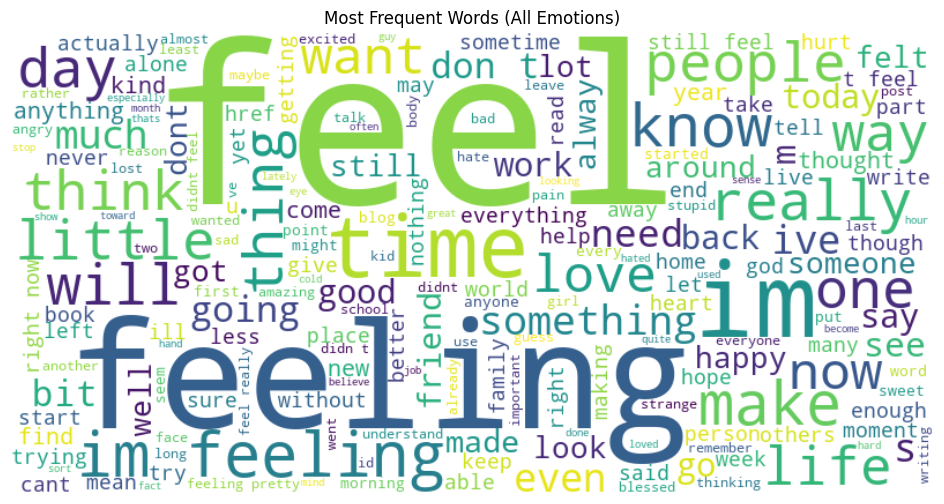

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

# Combine all text and clean it
all_text = ' '.join(df['text'].dropna()).lower()
all_text = re.sub(r'[^a-zA-Z ]+', ' ', all_text).strip()

if all_text:
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Most Frequent Words (All Emotions)")
    plt.show()
else:
    print("No valid text found for WordCloud.")


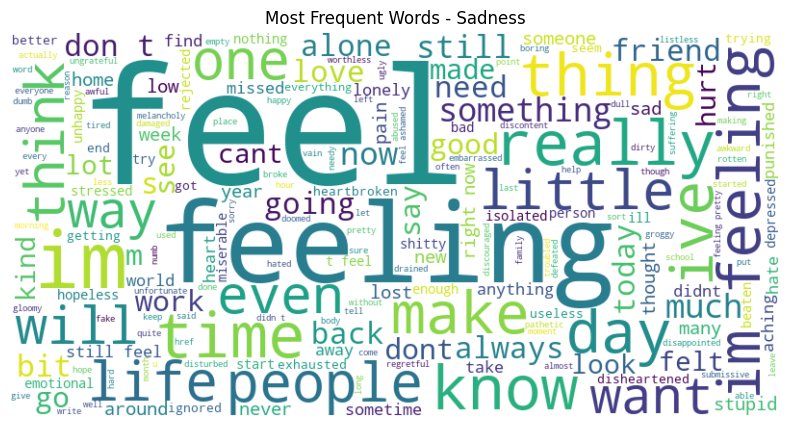

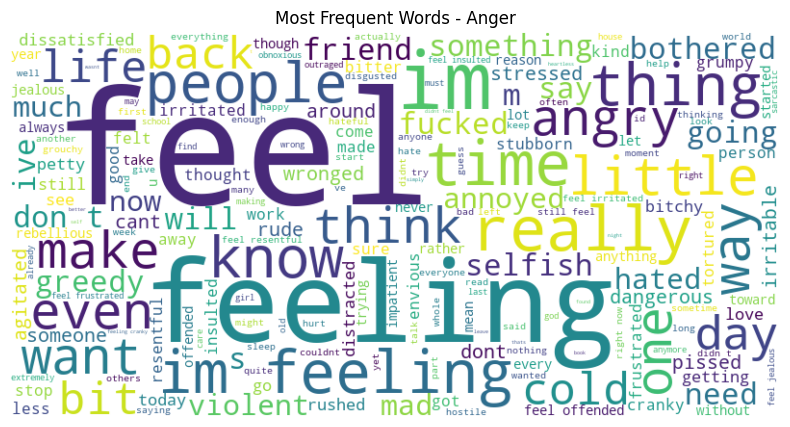

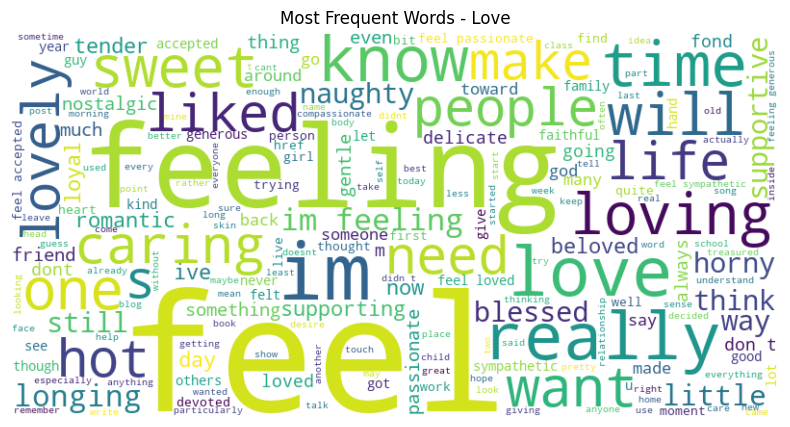

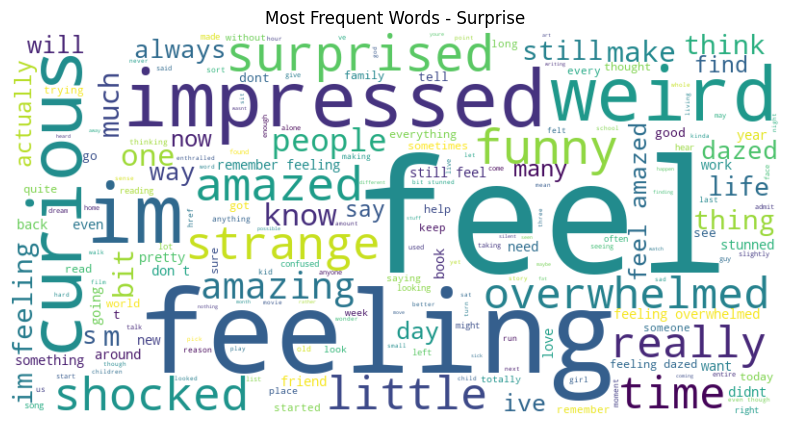

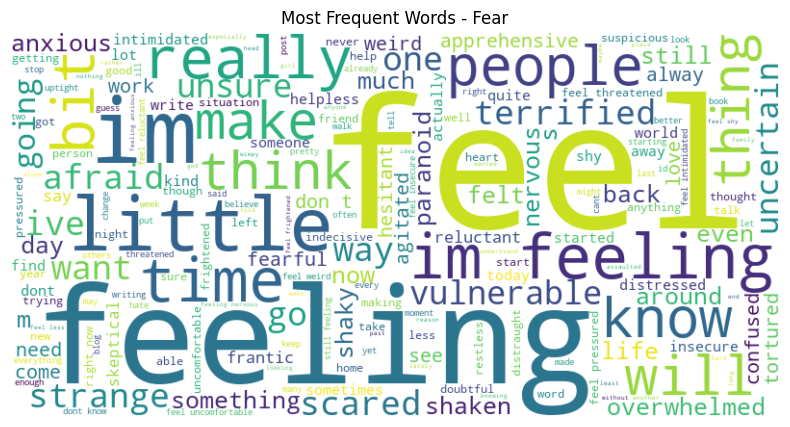

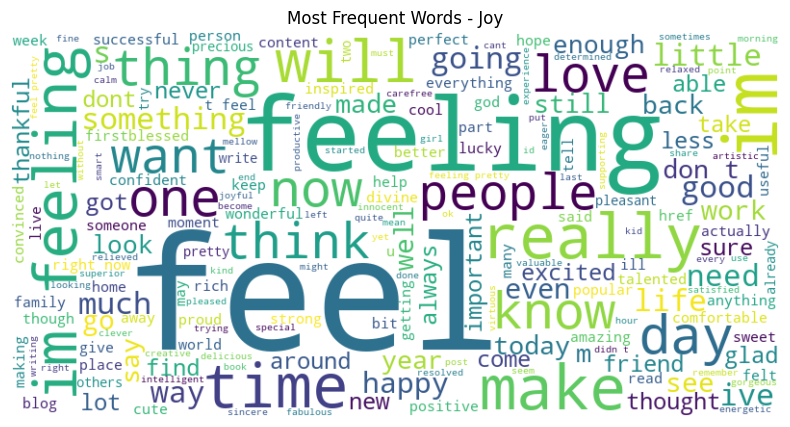

In [7]:
unique_labels = df['label'].unique()

for label in unique_labels:
    subset = df[df['label'] == label]['text'].dropna()
    label_text = ' '.join(subset).lower()
    label_text = re.sub(r'[^a-zA-Z ]+', ' ', label_text).strip()

    if label_text:
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(label_text)

        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"Most Frequent Words - {label.capitalize()}")
        plt.show()
    else:
        print(f"No valid text found for label: {label}")


Bar Plot of Emotion/Class Distribution

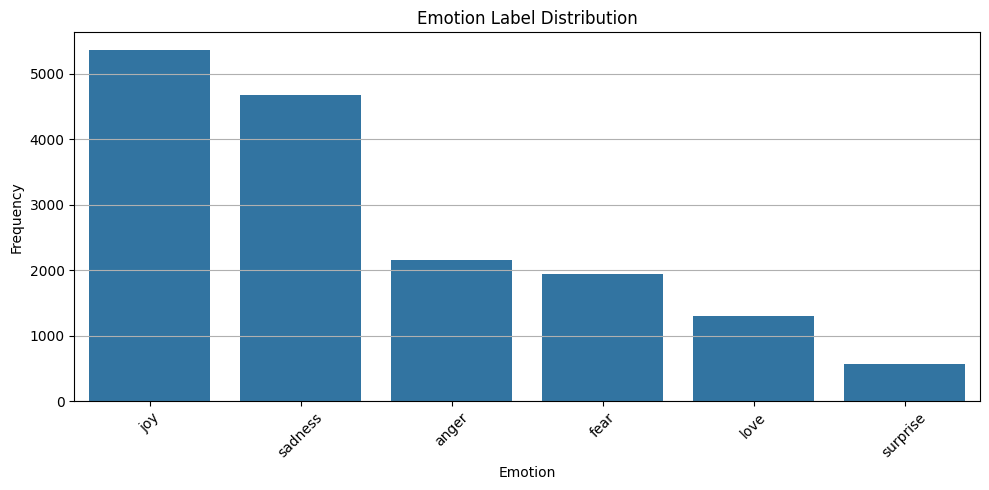

In [6]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title("Emotion Label Distribution")
plt.xlabel("Emotion")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


Preprocessing Step

Step 1: Basic Cleaning - 
We remove all non-alphabetic characters and convert the text to lowercase.

In [7]:
def basic_clean(text):
    text = re.sub(r'[^a-zA-Z ]', '', text)  # Keep only letters and spaces
    text = text.lower()                     # Convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip()# Remove extra whitespace
    return text

Step 2: Tokenization - We split the cleaned text into individual words (tokens).

In [8]:
def tokenize(text):
    return text.split()


Step 3 - Stopword Removal and Lemmatization

In [9]:
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_tokens(tokens): #di ko sure if tokens gid man ibutang di or text, nag ano ko sa gpt sakto man kuno ang tokens
    # Remove stopwords, lemmatize, then stem
    return [stemmer.stem(lemmatizer.lemmatize(word)) for word in tokens if word not in stop_words]


Let's Apply To The Dataset

In [10]:
import pandas as pd
from tabulate import tabulate

# Assuming you already have the following functions:
# basic_clean, tokenize, lemmatize_and_remove_stopwords

# Apply preprocessing to the entire training and validation data, kag ja nga part gin modify ko
df['cleaned_text'] = df['text'].apply(lambda x: ' '.join(
    preprocess_tokens(tokenize(basic_clean(x)))
))

val_df['cleaned_text'] = val_df['text'].apply(lambda x: ' '.join(
    preprocess_tokens(tokenize(basic_clean(x)))
))


# Convert the result into a table format using tabulate
df_table = tabulate(df[['text', 'cleaned_text']].head(), headers='keys', tablefmt='fancy_grid', showindex=False)
val_df_table = tabulate(val_df[['text', 'cleaned_text']].head(), headers='keys', tablefmt='fancy_grid', showindex=False)

# Display the formatted table
print("Preprocessed training data:")
print(df_table)

print("\nPreprocessed validation data:")
print(val_df_table)


Preprocessed training data:
╒══════════════════════════════════════════════════════════════════════════════════════════════════════════════╤════════════════════════════════════════════════════╕
│ text                                                                                                         │ cleaned_text                                       │
╞══════════════════════════════════════════════════════════════════════════════════════════════════════════════╪════════════════════════════════════════════════════╡
│ i didnt feel humiliated                                                                                      │ didnt feel humili                                  │
├──────────────────────────────────────────────────────────────────────────────────────────────────────────────┼────────────────────────────────────────────────────┤
│ i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake │ go feel hopeless damn hope ar

Now let's train the Model

First we need to vectorize the Text Data and add Embeddings

In [13]:
# Parameters for padding and tokenization
MAX_SEQUENCE_LENGTH = 100  # Set max sequence length
MAX_NUM_WORDS = 10000  # Set maximum number of words to use in the tokenizer

# Initialize the tokenizer
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS)

# Fit tokenizer on the training data
tokenizer.fit_on_texts(df['text'])

# Convert texts to sequences
X_train = tokenizer.texts_to_sequences(df['cleaned_text'])
X_val = tokenizer.texts_to_sequences(val_df['cleaned_text'])

# Pad sequences to ensure equal length
X_train_padded = pad_sequences(X_train, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_val_padded = pad_sequences(X_val, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

# Display the shape of the padded sequences to ensure correctness
print(f"Training data shape: {X_train_padded.shape}")
print(f"Validation data shape: {X_val_padded.shape}")


Training data shape: (16000, 100)
Validation data shape: (2000, 100)


In [14]:
# Create Custom Embedding Matrix (random initialization)
embedding_dim = 100  # Define the size of the embedding vectors

vocab_size = min(MAX_NUM_WORDS, len(tokenizer.word_index) + 1)  # Total number of unique words in the data
embedding_matrix = np.random.randn(vocab_size, embedding_dim)  # Random initialization for embeddings

# You can track how many words have been assigned embeddings:
hits = 0
misses = 0

# Optionally, you can initialize embedding_matrix with random values only for the tokens in the tokenizer's word_index
for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue  # Skip if the word index exceeds the vocab size
    # Assign a random vector to each word in the word index
    embedding_vector = np.random.randn(embedding_dim)  # Random vector for each word
    embedding_matrix[i] = embedding_vector
    hits += 1  # Track hits

print(f"Converted {hits} words with random embeddings")


Converted 9999 words with random embeddings


Converting Labels to Numeric Values

In [15]:
from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
label_encoder = LabelEncoder()

# Fit the encoder on the train data labels
y_train = label_encoder.fit_transform(df['label'])
y_val = label_encoder.transform(val_df['label'])  # Transform the validation data labels

# Display the label encoding mapping
label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Label encoding mapping:", label_mapping)

# Verify the conversion by displaying the first few labels from train and validation datasets
print(f"Encoded labels for the first 5 samples in train data: {y_train[:5]}")
print(f"Encoded labels for the first 5 samples in validation data: {y_val[:5]}")


Label encoding mapping: {'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5}
Encoded labels for the first 5 samples in train data: [4 4 0 3 0]
Encoded labels for the first 5 samples in validation data: [4 4 3 0 2]


Now let's build and train the LSTM Model

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Create the model
model = Sequential()

# Use the custom embedding matrix that you created manually
model.add(Embedding(
    input_dim=vocab_size,                   # Total number of tokens (rows in embedding_matrix)
    output_dim=embedding_dim,               # Dimension of the embedding vectors (e.g., 100)
    input_length=X_train_padded.shape[1],   # Max sequence length of input data
    weights=[embedding_matrix],             # Initialize with the manually created embedding matrix
    trainable=True                          # Set to True to allow fine-tuning the embeddings during training
))

# Add LSTM layers
model.add(Bidirectional(LSTM(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)))
model.add(Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)))
model.add(Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)))

# Output layer
model.add(Dense(6, activation='softmax'))  # 6 classes of emotions (adjust based on your dataset)

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer=Adam(0.005), metrics=['accuracy'])


model.build(input_shape=(None, X_train_padded.shape[1]))

# Summarize the model architecture
model.summary()


c:\Users\kengu\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 512)       │       731,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 100, 256)       │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,783,302 (10.62 MB)

 Trainable params: 2,783,302 (10.62 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from tensorflow.keras.utils import to_categorical

# y_train and y_val are integer labels (e.g., 0–5), we need to one-hot encode them
y_train_cat = to_categorical(y_train, num_classes=6)
y_val_cat = to_categorical(y_val, num_classes=6)


In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [19]:
history = model.fit(
    X_train_padded, y_train_cat,
    validation_data=(X_val_padded, y_val_cat),
    batch_size=256,
    epochs=10,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 412s 6s/step - accuracy: 0.2912 - loss: 1.6975 - val_accuracy: 0.3330 - val_loss: 1.5053
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 291s 5s/step - accuracy: 0.5203 - loss: 1.2168 - val_accuracy: 0.8360 - val_loss: 0.4442
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 316s 5s/step - accuracy: 0.8780 - loss: 0.3457 - val_accuracy: 0.9115 - val_loss: 0.2088
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 321s 5s/step - accuracy: 0.9417 - loss: 0.1480 - val_accuracy: 0.9300 - val_loss: 0.1881
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 328s 5s/step - accuracy: 0.9543 - loss: 0.1009 - val_accuracy: 0.9295 - val_loss: 0.1699
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 329s 5s/step - accuracy: 0.9647 - loss: 0.0776 - val_accuracy: 0.9245 - val_loss: 0.1759
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 334s 5s/step - accuracy: 0.9694 - loss: 0.0657 - val_accuracy: 0.9265 - val_loss: 0.2161


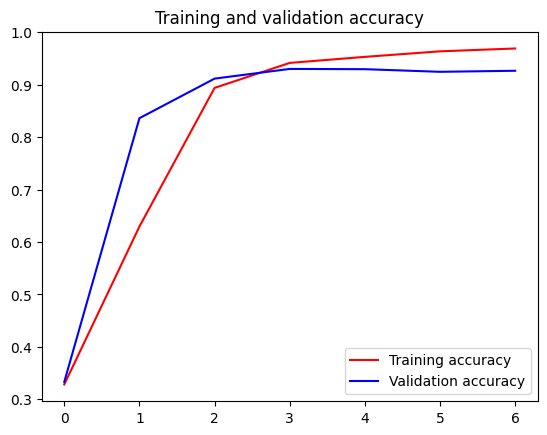

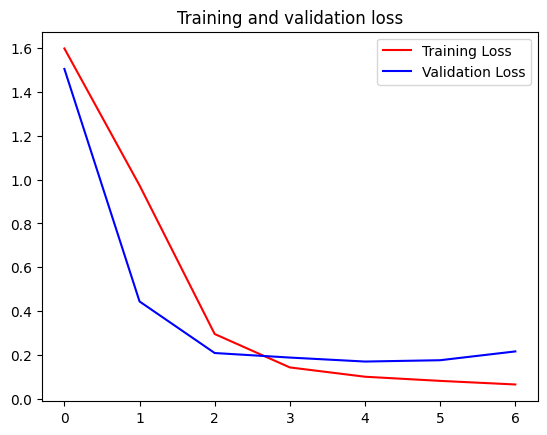

In [20]:
# Visualize Loss & Accuracy

%matplotlib inline
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [21]:
# Print final metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")


Final Training Accuracy: 0.9690
Final Validation Accuracy: 0.9265
Final Training Loss: 0.0652
Final Validation Loss: 0.2161


In [22]:
# model.save("lstm-2.h5")

In [23]:
import pickle

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

In [24]:
# Save the fitted LabelEncoder to a .pkl file
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("LabelEncoder saved as 'label_encoder.pkl'")

LabelEncoder saved as 'label_encoder.pkl'
